In [93]:
import numpy as np
import pandas as pd


In [94]:
url = "phishing_email.csv"

In [95]:
df = pd.read_csv(url)

In [96]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [97]:
# 0 → Legitimate email (normal / ham)
# 1 → Phishing or spam email (anomalous)

In [98]:
df.shape

(82486, 2)

In [99]:
df['label'].value_counts()

label
1    42891
0    39595
Name: count, dtype: int64

In [100]:
df.isna().sum()

text_combined    0
label            0
dtype: int64

In [101]:
df[df['label'] == 1]['text_combined'].head(10)

3503    link dwl g 510 802 11 g wireless pci lan adapt...
3504    indemand payperview movies sports wed 15 sep 2...
3505    want lose 19 weight try adipren hello special ...
3506    cialis xanax valium viagra low price prescript...
3507    pre order see image click indelible backscatte...
3508    site links site hello name anthony lewis seeki...
3509     htmlbody font style font size 3 difcoxw pjgfe...
3510    find sex addicts area costless dating website ...
3511    code yr 983795 hi sent email last week like co...
3512    work full time earning degree wish remove futu...
Name: text_combined, dtype: object

In [102]:
df[df['label'] == 1]['text_combined'].head(5)

3503    link dwl g 510 802 11 g wireless pci lan adapt...
3504    indemand payperview movies sports wed 15 sep 2...
3505    want lose 19 weight try adipren hello special ...
3506    cialis xanax valium viagra low price prescript...
3507    pre order see image click indelible backscatte...
Name: text_combined, dtype: object

In [103]:
df.head(10)

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0
5,hpl nom may 31 2001 see attached file hplno 53...,0
6,9760 tried get fancy address came back forward...,0
7,hpl noms february 15 2000 see attached file hp...,0
8,fw pooling contract template original message ...,0
9,hpl nom march 28 2000 see attached file hplo 3...,0


In [104]:
df_small = df[['text_combined', 'label']].dropna()
df_small.shape, df_small['label'].value_counts()


((82486, 2),
 label
 1    42891
 0    39595
 Name: count, dtype: int64)

In [105]:
df_small.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [106]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

In [107]:
texts = df_small['text_combined'].tolist()

X = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True
)

Batches:   0%|          | 0/1289 [00:00<?, ?it/s]

In [132]:
import numpy as np

np.save("X_embeddings.npy", X)
y = df_small['label'].values
np.save("y_labels.npy", df_small['label'].values)

In [133]:
X.shape

(82486, 384)

In [134]:
from sklearn.metrics.pairwise import cosine_similarity

e1 = X[0]
e2 = X[1]

cosine_similarity([e1], [e2])


array([[0.2825678]], dtype=float32)

In [135]:
# ham vs ham
cosine_similarity([X[y==0][0]], [X[y==0][1]])

# ham vs spam
cosine_similarity([X[y==0][0]], [X[y==1][0]])


array([[0.19110566]], dtype=float32)

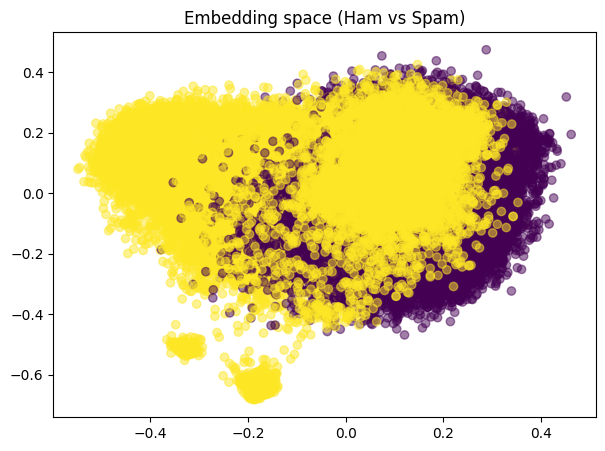

In [136]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, alpha=0.5)
plt.title("Embedding space (Ham vs Spam)")
plt.show()


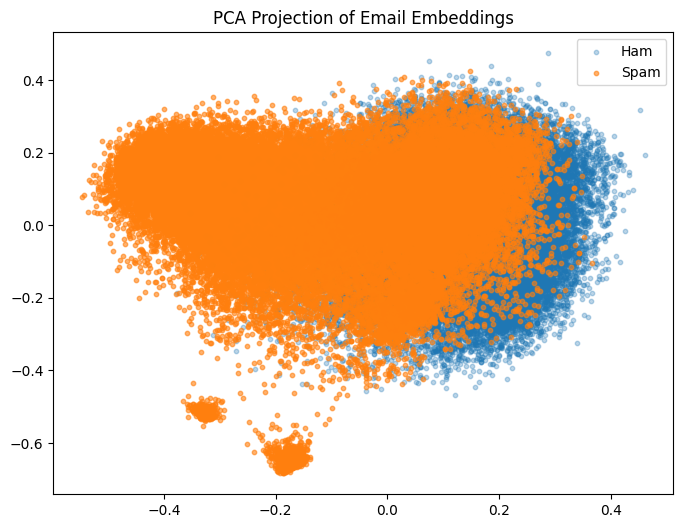

In [137]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

y = df_small['label'].values

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(X_2d[y==0,0], X_2d[y==0,1], 
            alpha=0.3, label='Ham', s=10)

plt.scatter(X_2d[y==1,0], X_2d[y==1,1], 
            alpha=0.6, label='Spam', s=10)

plt.legend()
plt.title("PCA Projection of Email Embeddings")
plt.show()

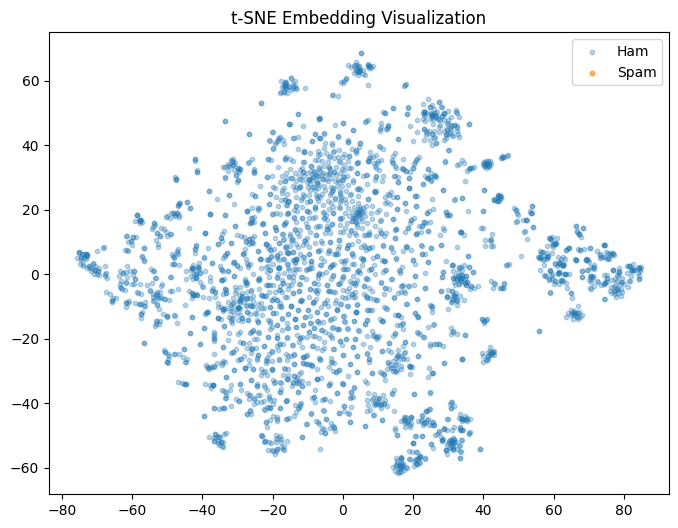

In [138]:
from sklearn.manifold import TSNE

X_sample = X[:3000]
y_sample = y[:3000]

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8,6))

plt.scatter(X_tsne[y_sample==0,0], X_tsne[y_sample==0,1],
            alpha=0.3, label='Ham', s=10)

plt.scatter(X_tsne[y_sample==1,0], X_tsne[y_sample==1,1],
            alpha=0.6, label='Spam', s=10)

plt.legend()
plt.title("t-SNE Embedding Visualization")
plt.show()


In [139]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

ham_vecs = X[y==0]
spam_vecs = X[y==1]

# take small subset for speed
ham_subset = ham_vecs[:500]
spam_subset = spam_vecs[:500]

# ham vs ham similarity
ham_sim = cosine_similarity(ham_subset, ham_subset).mean()

# spam vs spam similarity
spam_sim = cosine_similarity(spam_subset, spam_subset).mean()

# ham vs spam similarity
cross_sim = cosine_similarity(ham_subset, spam_subset).mean()

print("Ham-Ham similarity:", ham_sim)
print("Spam-Spam similarity:", spam_sim)
print("Ham-Spam similarity:", cross_sim)


Ham-Ham similarity: 0.5400469
Spam-Spam similarity: 0.23211233
Ham-Spam similarity: 0.16711824


In [140]:
query = X[y==1][0]   # pick a spam email

sims = cosine_similarity([query], X)[0]
top_idx = sims.argsort()[-10:]

df_small.iloc[top_idx][['text_combined','label']]

,text_combined,label
20790,wireless pda 44 00 nec mobilepro p 300 802 11 ...,1
20174,netgear 5 1 wireless 69 00 netgear cable dsl p...,1
4191,108 mbps wireless firewall 4 port router 59 00...,1
19623,netgear 54 mbps wireless pc card 34 50 p e c l...,1
20186,link airplus g 802 11 g wireless router 87 00 ...,1
4746,link airplus g 802 11 g wireless router 87 00 ...,1
4839,xterasys 802 11 g 54 mbps wireless pc card 29 ...,1
19462,new wireless products wireless products 14 35 ...,1
17897,54 mbps wireless usb adapter 802 11 b g wirele...,1
3503,link dwl g 510 802 11 g wireless pci lan adapt...,1


In [157]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_recall_fscore_support, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Load saved arrays (or use X, y already in memory)
X = np.load("X_embeddings.npy")           # (20000, 384)
y = np.load("y_labels.npy")              # (20000,)

X = X.astype(np.float32)
y = y.astype(np.int64)

X_train = X[y == 0]   # ham only
X_test  = X           # evaluate on all
y_test  = y
print("X_train:", X_train.shape, "X_test:", X_test.shape)


device: cuda
X_train: (39595, 384) X_test: (82486, 384)


In [158]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=384, h1=256, h2=128, latent=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, h2),
            nn.ReLU(),
            nn.Linear(h2, h1),
            nn.ReLU(),
            nn.Linear(h1, input_dim),  # output linear
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


In [159]:
torch.manual_seed(42)

train_ds = TensorDataset(torch.from_numpy(X_train))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)

model = AutoEncoder(input_dim=X.shape[1], h1=256, h2=128, latent=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

model.train()
for ep in range(1, epochs + 1):
    total_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs} | train MSE: {avg_loss:.6f}")


Epoch 01/30 | train MSE: 0.001769
Epoch 05/30 | train MSE: 0.001170
Epoch 10/30 | train MSE: 0.001111
Epoch 15/30 | train MSE: 0.001079
Epoch 20/30 | train MSE: 0.001060
Epoch 25/30 | train MSE: 0.001046
Epoch 30/30 | train MSE: 0.001036


In [160]:
@torch.no_grad()
def recon_errors(model, X_np, batch_size=512):
    model.eval()
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=batch_size, shuffle=False)
    for (batch,) in loader:
        batch = batch.to(device)
        recon = model(batch)
        per_sample = torch.mean((recon - batch) ** 2, dim=1)  # MSE per sample
        errs.append(per_sample.detach().cpu().numpy())
    return np.concatenate(errs)

train_err = recon_errors(model, X_train)
test_err  = recon_errors(model, X_test)

print("train_err:", train_err.shape, "test_err:", test_err.shape)
print("train_err mean/std:", train_err.mean(), train_err.std())


train_err: (39595,) test_err: (82486,)
train_err mean/std: 0.0010301168 0.00035135786


In [161]:
threshold = train_err.mean() + 2 * train_err.std()
y_pred = (test_err > threshold).astype(int)  # 1 = anomaly/spam

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
print("threshold:", threshold)
print("Precision:", prec, "Recall:", rec, "F1:", f1)

print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))


threshold: 0.0017328325
Precision: 0.942816953091554 Recall: 0.35942272271572123 F1: 0.5204415786097701

Classification report:
               precision    recall  f1-score   support

           0       0.58      0.98      0.73     39595
           1       0.94      0.36      0.52     42891

    accuracy                           0.66     82486
   macro avg       0.76      0.67      0.63     82486
weighted avg       0.77      0.66      0.62     82486



In [162]:
torch.save(model.state_dict(), "autoencoder_fp32.pth")
checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": 384,
    "h1": 256,
    "h2": 128,
    "latent": 64
}

torch.save(checkpoint, "autoencoder_fp32_full.pth")

In [163]:
torch.save(model.state_dict(), "autoencoder_fp32.pth")


In [164]:
model_fp16 = AutoEncoder(input_dim=384, h1=256, h2=128, latent=16).to(device)
model_fp16.load_state_dict(torch.load("autoencoder_fp32.pth"))

model_fp16 = model_fp16.half()   # convert weights to float16
model_fp16.eval()


AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=384, bias=True)
  )
)

In [165]:
model_fp16 = AutoEncoder(input_dim=384, h1=256, h2=128, latent=16).to(device)
model_fp16.load_state_dict(torch.load("autoencoder_fp32.pth"))

model_fp16 = model_fp16.half()   # convert weights to float16
model_fp16.eval()


AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=384, bias=True)
  )
)

In [166]:
@torch.no_grad()
def recon_errors_fp16(model, X_np, batch_size=512):
    model.eval()
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=batch_size, shuffle=False)

    for (batch,) in loader:
        batch = batch.to(device).half()   # IMPORTANT
        recon = model(batch)
        per_sample = torch.mean((recon - batch) ** 2, dim=1)
        errs.append(per_sample.detach().cpu().numpy())

    return np.concatenate(errs)


In [167]:
train_err_fp16 = recon_errors_fp16(model_fp16, X_train)
test_err_fp16  = recon_errors_fp16(model_fp16, X_test)


In [168]:
y_pred_fp16 = (test_err_fp16 > threshold).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_fp16, average="binary", zero_division=0
)

print("FP16 Results")
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)


FP16 Results
Precision: 0.942801151325862
Recall: 0.35893310951015367
F1: 0.5199257007767646


In [169]:
import torch.quantization

model_fp32_cpu = AutoEncoder(input_dim=384, h1=256, h2=128, latent=16)
model_fp32_cpu.load_state_dict(torch.load("autoencoder_fp32.pth", map_location="cpu"))
model_fp32_cpu.eval()

model_int8 = torch.quantization.quantize_dynamic(
    model_fp32_cpu,
    {torch.nn.Linear},
    dtype=torch.qint8
)
model_int8.eval()



AutoEncoder(
  (encoder): Sequential(
    (0): DynamicQuantizedLinear(in_features=384, out_features=256, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (1): ReLU()
    (2): DynamicQuantizedLinear(in_features=256, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (3): ReLU()
    (4): DynamicQuantizedLinear(in_features=128, out_features=16, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  )
  (decoder): Sequential(
    (0): DynamicQuantizedLinear(in_features=16, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (1): ReLU()
    (2): DynamicQuantizedLinear(in_features=128, out_features=256, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (3): ReLU()
    (4): DynamicQuantizedLinear(in_features=256, out_features=384, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  )
)

In [170]:
@torch.no_grad()
def recon_errors_cpu(model, X_np, batch_size=512):
    model.eval()
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=batch_size, shuffle=False)
    for (batch,) in loader:
        batch = batch.float()          # keep float32 input on CPU
        recon = model(batch)           # model runs on CPU
        per_sample = torch.mean((recon - batch) ** 2, dim=1)
        errs.append(per_sample.numpy())
    return np.concatenate(errs)



In [171]:
train_err_int8 = recon_errors_cpu(model_int8, X_train)
test_err_int8  = recon_errors_cpu(model_int8, X_test)

y_pred_int8 = (test_err_int8 > threshold).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_int8, average="binary", zero_division=0
)

print("INT8 Results")
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)


INT8 Results
Precision: 0.9419147517128479
Recall: 0.362197197547271
F1: 0.5232049036777583
